<a href="https://colab.research.google.com/github/Ajay9760/Hospital-Readmission-RIsk/blob/main/Hospital_Readmission_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Readmission Risk — Diabetic Patients

**Question:** Which patients are at high risk of being readmitted within 30 days of discharge, and what factors drive that risk?

**Why this framing, not just "predict readmitted":** a care team can't act on "readmitted: yes/no" alone — they need to know *who* to prioritize for follow-up and *why*, so the discharge-planning takeaway has to come out of this as clearly as the model does.

**Dataset:** Diabetes 130-US Hospitals (1999–2008), Strack et al. (2014), via UCI ML Repository (CC BY 4.0). 101,766 inpatient encounters across 130 hospitals, patients with any diabetes diagnosis, length of stay 1–14 days.

In [54]:
import warnings
warnings.filterwarnings('ignore')

In [55]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 60)

df = pd.read_csv("/content/diabetic_data.csv", na_values="?")
print("Shape:", df.shape)
df.head(3)

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


## 1. First look at the target

`readmitted` has three values: `NO`, `>30` (readmitted, but after 30 days), `<30` (readmitted within 30 days — this is our positive class).

Binarize it: `<30` → 1, everything else → 0.

In [56]:
print(df['readmitted'].value_counts())
print()
print(df['readmitted'].value_counts(normalize=True).round(3))

df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
print()
print(f"Positive class rate: {df['readmitted_30d'].mean():.1%}")

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64

Positive class rate: 11.2%


**~11% positive class.** This is meaningfully imbalanced — accuracy will be a useless metric here (a model that always predicts "no readmission" gets ~89% accuracy while being clinically useless). Keep this in mind for the modeling stage: precision/recall/F1/ROC-AUC, not accuracy.

## 2. A leakage trap most people miss

Check unique patients vs. total encounters.

In [57]:
print("Encounters:", len(df))
print("Unique patients:", df['patient_nbr'].nunique())
print("Patients with >1 encounter:", (df['patient_nbr'].value_counts() > 1).sum())

Encounters: 101766
Unique patients: 71518
Patients with >1 encounter: 16773


**This matters a lot.** ~30,000 patients appear more than once. If you do a random row-level train/test split, the *same patient* can end up in both train and test — the model partly "memorizes" that patient instead of learning general risk patterns, and your test metrics will look better than the model actually is in production.

> **YOUR TURN:** When you get to the train/test split later, split by `patient_nbr` (e.g. `sklearn.model_selection.GroupShuffleSplit` with `groups=df['patient_nbr']`), not a plain random split. Come back to this cell as a reminder.

## 3. Missingness

In [58]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(missing.round(1))

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64


**YOUR TURN — for each of these, decide and write down *why* (this is the part an interviewer will actually ask about):**

| Column | Missing % | Question to answer yourself |
|---|---|---|
| `weight` | ~97% | Is this salvageable at all, or should it just be dropped? What would you say if asked "why drop a column instead of imputing it"? |
| `max_glu_serum` | ~95% | Same question — but note this one might be missing *because the test wasn't ordered*, not because data was lost. Is "missing" itself informative here? |
| `A1Cresult` | ~83% | Same "is missingness informative" question as above. |
| `medical_specialty` | ~49% | Drop, impute as "Unknown" category, or bucket rare specialties together? |
| `payer_code` | ~40% | Is this even relevant to a *clinical* readmission-risk question, or is it noise for this particular question? |
| `race` | ~2% | Small enough to just drop those rows, or impute? |

Don't just pick the popular answer from a tutorial — pick one, and be ready to explain the tradeoff out loud.

## 4. A quick first signal — does length of stay relate to readmission?

time_in_hospital
1     0.082
2     0.099
3     0.107
4     0.118
5     0.120
6     0.126
7     0.128
8     0.142
9     0.137
10    0.143
11    0.105
12    0.133
13    0.123
14    0.130
Name: readmitted_30d, dtype: float64


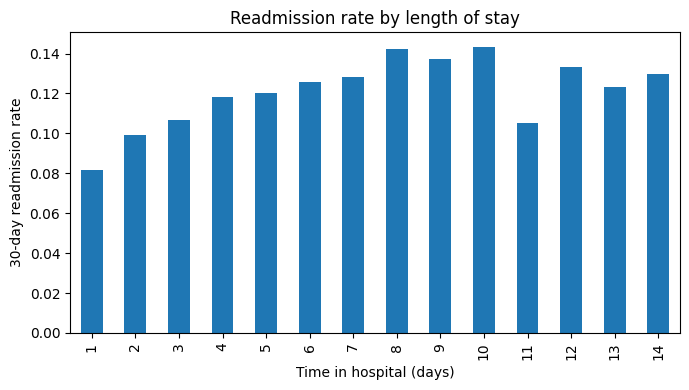

In [59]:
import matplotlib.pyplot as plt

readmit_rate_by_los = df.groupby('time_in_hospital')['readmitted_30d'].mean()
print(readmit_rate_by_los.round(3))

fig, ax = plt.subplots(figsize=(7,4))
readmit_rate_by_los.plot(kind='bar', ax=ax)
ax.set_xlabel("Time in hospital (days)")
ax.set_ylabel("30-day readmission rate")
ax.set_title("Readmission rate by length of stay")
plt.tight_layout()
plt.savefig("outputs_readmit_by_los.png", dpi=120)
plt.show()

## Next steps (yours to work through)

1. **Decide and justify** each missingness call from section 3 — write your reasoning in a markdown cell, not just code.
2. **A couple more EDA angles worth checking** before you move to modeling: readmission rate by `age` bucket, by `number_inpatient` (prior admissions), and by `discharge_disposition_id` (some codes mean "discharged to hospice/deceased" — should those rows even be in the model?).
3. **Feature engineering**: encode categoricals, map `diag_1/2/3` ICD-9 codes into broader categories (circulatory, respiratory, diabetes, etc. — mapping tables exist in `IDS_mapping.csv` and standard ICD-9 chapter ranges) rather than one-hot encoding hundreds of raw codes.
4. **Patient-level train/test split** (see section 2).
5. **Baseline model**: Logistic Regression. Then compare Random Forest / Gradient Boosting.
6. **Evaluate**: precision/recall/F1/ROC-AUC, and look at a confusion matrix in real numbers ("of 2,000 flagged high-risk patients, how many were true positives?") — that's the version a non-technical interviewer or stakeholder can actually follow.
7. **Interpret**: feature importances → translate into a plain-English clinical takeaway.
8. **Write the README**: question → approach → results → limitations → what you'd do with more time.

Bring your results back and I'll help you stress-test the reasoning before you write it up.

In [60]:
df.duplicated().sum()

np.int64(0)

**`weight` (96.9% missing)**: Drop this column entirely. Attempting to impute 97% of a variable introduces massive artificial bias that will distort the model's logic.

**`max_glu_serum` (94.7%) & `A1Cresult` (83.3% missing)**: Retain and fill with "Not_Measured". In clinical workflows, the *decision not to order a test* is informative. It often signals that the physician did not suspect acute diabetic complications.

**`medical_specialty` (49.1% missing)**: Impute as "Missing". The admitting specialty (e.g., Cardiology vs. Internal Medicine) is a strong proxy for patient acuity and primary disease category.

**`payer_code` (39.6% missing)**: Impute as "Missing". Insurance type frequently acts as a proxy for socioeconomic status and outpatient healthcare access, which heavily influence readmission risk.

**`race` (2.2% missing)**: Drop these rows. The data loss is negligible. *(Note: Also dropping the ~1.5% of rows missing `diag_1`, `diag_2`, or `diag_3` to prevent low-support dummy variables from creating exploding, unstable coefficients during modeling).*

In [61]:
# 1. Handle missing data
df.drop('weight', axis=1, inplace=True)
df['max_glu_serum'].fillna('Not_Measured', inplace=True)
df['A1Cresult'].fillna('Not_Measured', inplace=True)
df['medical_specialty'].fillna('Missing', inplace=True)
df['payer_code'].fillna('Missing', inplace=True)

# Drop rows missing demographic or primary diagnosis data to prevent coefficient explosion
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace=True)

# Drop deceased/hospice patients (Discharge IDs 11, 13, 14, 19, 20, 21)
terminal_codes = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(terminal_codes)]

# 2. EDA
print("Readmission Rate by Age Bucket:\n", df.groupby('age')['readmitted_30d'].mean().round(3))
print("\nReadmission Rate by Prior Inpatient Visits:\n", df.groupby('number_inpatient')['readmitted_30d'].mean().round(3))

Readmission Rate by Age Bucket:
 age
[0-10)      0.016
[10-20)     0.067
[20-30)     0.145
[30-40)     0.115
[40-50)     0.108
[50-60)     0.099
[60-70)     0.115
[70-80)     0.122
[80-90)     0.125
[90-100)    0.118
Name: readmitted_30d, dtype: float64

Readmission Rate by Prior Inpatient Visits:
 number_inpatient
0     0.087
1     0.133
2     0.178
3     0.211
4     0.242
5     0.319
6     0.348
7     0.365
8     0.468
9     0.431
10    0.431
11    0.667
12    0.516
13    0.556
14    0.400
15    1.000
16    0.200
18    0.000
19    0.500
21    1.000
Name: readmitted_30d, dtype: float64


In [62]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,0


In [63]:
# Helper to bucket ICD-9 codes
def map_icd9(val):
    try:
        num_val = float(val.split('V')[0].split('E')[0]) if 'V' not in str(val) and 'E' not in str(val) else -1
        if 390 <= num_val <= 459 or num_val == 785: return 'Circulatory'
        elif 460 <= num_val <= 519 or num_val == 786: return 'Respiratory'
        elif 520 <= num_val <= 579 or num_val == 787: return 'Digestive'
        elif str(val).startswith('250'): return 'Diabetes'
        elif 800 <= num_val <= 999: return 'Injury'
        elif 710 <= num_val <= 739: return 'Musculoskeletal'
        elif 580 <= num_val <= 629 or num_val == 788: return 'Genitourinary'
        elif 140 <= num_val <= 239: return 'Neoplasms'
        else: return 'Other'
    except:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[f'{col}_category'] = df[col].apply(map_icd9)
    df.drop(col, axis=1, inplace=True)

# Define features (Including diag_3_category)
features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_inpatient', 'number_diagnoses',
            'max_glu_serum', 'A1Cresult', 'diabetesMed',
            'diag_1_category', 'diag_2_category', 'diag_3_category']

X = pd.get_dummies(df[features], drop_first=True)
y = df['readmitted_30d']
groups = df['patient_nbr']

In [64]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Patient-level split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# Standardize continuous variables AFTER splitting to prevent data leakage
continuous_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                   'num_medications', 'number_inpatient', 'number_diagnoses']

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# Train Baseline
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.78     16848
           1       0.17      0.49      0.25      2185

    accuracy                           0.66     19033
   macro avg       0.54      0.59      0.51     19033
weighted avg       0.83      0.66      0.72     19033



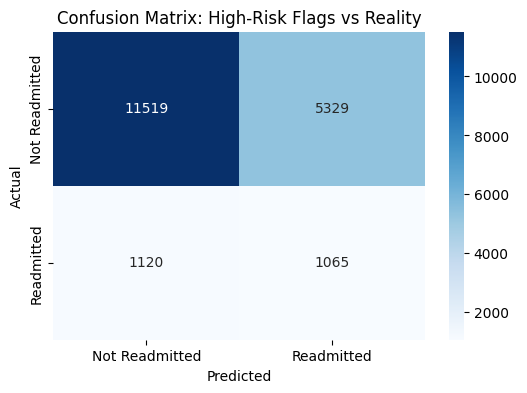


Top Reliable Predictors (Standardized & Filtered):
                             Feature  Coefficient  Train_Support
35        diag_2_category_Neoplasms     0.389575         1801.0
4                  number_inpatient     0.389141            NaN
6                       age_[10-20)    -0.347682          381.0
29      diag_1_category_Respiratory    -0.300624        10738.0
43        diag_3_category_Neoplasms     0.240440         1302.0
13                      age_[80-90)     0.186350        12742.0
30         diag_2_category_Diabetes     0.184324         9435.0
26  diag_1_category_Musculoskeletal    -0.176170         3837.0
40    diag_3_category_Genitourinary     0.164816         5018.0
20           A1Cresult_Not_Measured     0.152919        63798.0


In [65]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: High-Risk Flags vs Reality')
plt.show()

# 2. Sanity-Checked Feature Importances
dummy_cols = [c for c in X_train.columns if c not in continuous_cols]
support = X_train[dummy_cols].sum()

coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
})
coefs['Train_Support'] = coefs['Feature'].map(support)

# Filter out dummy variables with dangerously low support (<100 occurrences in training)
reliable_coefs = coefs[(coefs['Train_Support'] >= 100) | (coefs['Train_Support'].isna())]

print("\nTop Reliable Predictors (Standardized & Filtered):\n",
      reliable_coefs.sort_values(by='Coefficient', key=abs, ascending=False).head(10))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83     16848
           1       0.18      0.41      0.25      2185

    accuracy                           0.72     19033
   macro avg       0.54      0.58      0.54     19033
weighted avg       0.82      0.72      0.76     19033

Random Forest ROC-AUC: 0.631


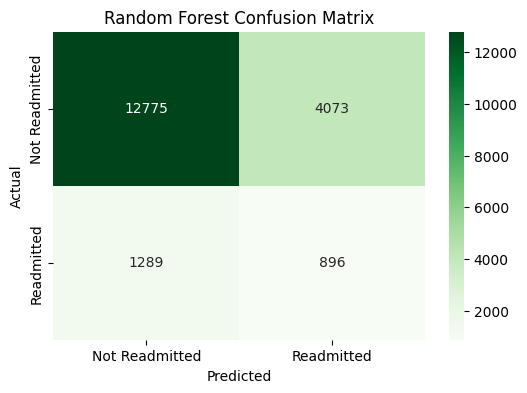

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Train Random Forest (max_depth limits overfitting, n_jobs=-1 speeds up training)
rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()

**Threshold Tuning vs. Default Predictions**
By default, classification models use a 50% probability cutoff to flag a patient. However, if our hospital care team only has the resources to make 400 follow-up calls this month, a 50% cutoff that flags 2,000 patients is operationally useless.

By tuning the threshold to only flag the **top 20% highest-risk patients**, we shift the model's output to match the care team's real-world capacity.
* **Recall decreases:** We will miss some borderline readmissions by narrowing our focus.
* **Precision increases:** The patients we *do* flag are highly concentrated with true positives, meaning the care team wastes less time chasing false alarms.

Operational Target: Flagging the top 20% highest-risk patients.
Calculated Probability Threshold: 0.521

Adjusted Threshold Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86     16848
           1       0.19      0.33      0.24      2185

    accuracy                           0.76     19033
   macro avg       0.55      0.57      0.55     19033
weighted avg       0.82      0.76      0.79     19033



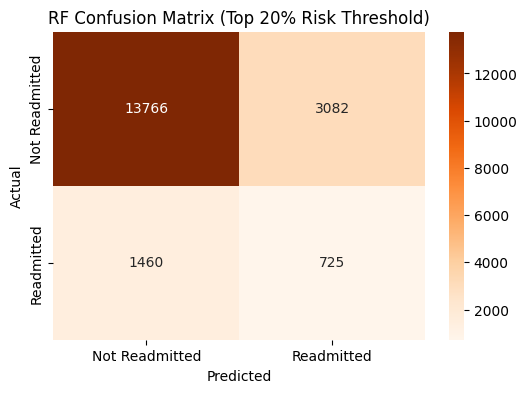

In [67]:
import numpy as np

# Define how many patients the care team can reasonably follow up with (e.g., top 20%)
top_percent = 20
percentile_target = 100 - top_percent

# Find the exact probability score that corresponds to that percentile
custom_threshold = np.percentile(rf_prob, percentile_target)

print(f"Operational Target: Flagging the top {top_percent}% highest-risk patients.")
print(f"Calculated Probability Threshold: {custom_threshold:.3f}\n")

# Apply the new threshold (1 if prob >= threshold, else 0)
rf_custom_pred = (rf_prob >= custom_threshold).astype(int)

# Re-evaluate precision and recall
print("Adjusted Threshold Classification Report:\n", classification_report(y_test, rf_custom_pred))

# Visualizing the operational impact
cm_custom = confusion_matrix(y_test, rf_custom_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'RF Confusion Matrix (Top {top_percent}% Risk Threshold)')
plt.show()

In [68]:
# Extract RF Feature Importances
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'RF_Importance': rf.feature_importances_
}).sort_values(by='RF_Importance', ascending=False)

print("Top 10 Random Forest Predictors:\n", rf_importances.head(10))

# Compare with Logistic Regression (using reliable_coefs)
top_rf_features = set(rf_importances.head(15)['Feature'])
top_lr_features = set(reliable_coefs.sort_values(by='Coefficient', key=abs, ascending=False).head(15)['Feature'])

consensus_drivers = top_rf_features.intersection(top_lr_features)

print("\nConsensus Drivers (Top predictors agreeing across BOTH models):")
for feature in consensus_drivers:
    # Fetch directionality from LR (using reliable_coefs)
    lr_direction = "Increases Risk" if reliable_coefs.loc[reliable_coefs['Feature'] == feature, 'Coefficient'].values[0] > 0 else "Decreases Risk"
    print(f"- {feature} ({lr_direction})")

Top 10 Random Forest Predictors:
                         Feature  RF_Importance
4              number_inpatient       0.260031
1            num_lab_procedures       0.097622
3               num_medications       0.097466
0              time_in_hospital       0.079263
5              number_diagnoses       0.058203
2                num_procedures       0.046973
21              diabetesMed_Yes       0.017873
29  diag_1_category_Respiratory       0.015102
10                  age_[50-60)       0.014123
20       A1Cresult_Not_Measured       0.013411

Consensus Drivers (Top predictors agreeing across BOTH models):
- age_[70-80) (Increases Risk)
- diabetesMed_Yes (Increases Risk)
- number_inpatient (Increases Risk)
- age_[80-90) (Increases Risk)
- diag_1_category_Respiratory (Decreases Risk)
- A1Cresult_Not_Measured (Increases Risk)


Operational Lift Curve:

 Top % Flagged  Prob Threshold  Precision  Recall
             5           0.610      0.235   0.103
            10           0.568      0.218   0.190
            15           0.542      0.206   0.269
            20           0.521      0.190   0.332
            25           0.503      0.183   0.399
            30           0.489      0.173   0.453
            40           0.464      0.160   0.557
            50           0.440      0.150   0.652


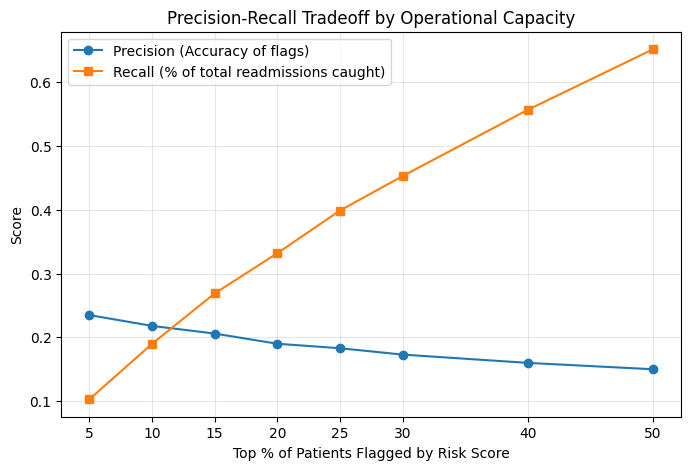

In [69]:
from sklearn.metrics import precision_score, recall_score

# 1. Generate the Lift Curve Data
percentiles_to_test = [5, 10, 15, 20, 25, 30, 40, 50]
results = []

for p in percentiles_to_test:
    threshold = np.percentile(rf_prob, 100 - p)
    preds = (rf_prob >= threshold).astype(int)
    results.append({
        'Top % Flagged': p,
        'Prob Threshold': round(threshold, 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall': round(recall_score(y_test, preds), 3)
    })

lift_df = pd.DataFrame(results)
print("Operational Lift Curve:\n")
print(lift_df.to_string(index=False))

# 2. Visualize the Trade-off
plt.figure(figsize=(8, 5))
plt.plot(lift_df['Top % Flagged'], lift_df['Precision'], marker='o', label='Precision (Accuracy of flags)')
plt.plot(lift_df['Top % Flagged'], lift_df['Recall'], marker='s', label='Recall (% of total readmissions caught)')
plt.title("Precision-Recall Tradeoff by Operational Capacity")
plt.xlabel("Top % of Patients Flagged by Risk Score")
plt.ylabel("Score")
plt.xticks(percentiles_to_test)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
import joblib
import json

# Save the models and scaler
joblib.dump(lr, 'logistic_regression_model.joblib')
joblib.dump(rf, 'random_forest_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

# Save the expected columns for the app
with open('scaled_columns.json', 'w') as f:
    json.dump(continuous_cols, f)

with open('model_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

